**Objetivo especifico 2:** Implementar modelos de ML que relacionen el proteoma de los pacientes con la progresión de la enfermedad con la finalidad de evaluar la capacidad predictiva de los modelos y determinar la importancia de las características proteómicas.

Los datos originales para realizar la simulación se obtuvieron a partir del trabajo citado a continuación: Garg NJ, Soman KV, Zago MP, Koo S-J, Spratt H, Stafford S, et al. (2016) Changes in Proteome Profile of Peripheral Blood Mononuclear Cells in Chronic Chagas Disease. PLoS Negl Trop Dis 10(2): e0004490. doi:10.1371/journal. pntd.0004490.

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

In [ ]:
#  Subir el dataset sintético generado en el Objetivo 1
subida = files.upload()
archivo = list(subida.keys())[0]

dataset_final = pd.read_csv(archivo)

print("Archivo subido ok ✅")
print("Filas:", dataset_final.shape[0], " Columnas:", dataset_final.shape[1])
dataset_final.head(10)

Saving dataset_sintetico_pbmc.csv to dataset_sintetico_pbmc.csv
Archivo subido ok ✅
Filas: 83  Columnas: 194


,"Actin, alpha 1, skeletal muscle_spot890","Actin, alpha 1, skeletal muscle_spot121","Actin, cytoplasmic 1_spot769","Actin, cytoplasmic 1_spot679","Actin, cytoplasmic 1_spot629","Actin, cytoplasmic 1_spot303","Actin, cytoplasmic 1_spot657","Actin, cytoplasmic 1_spot642","Actin, cytoplasmic 1_spot621","Actin, cytoplasmic 1_spot896",...,Vimentin_spot312,Vimentin_spot307,Vinculin_spot52,Vinculin_spot59,Vinculin isoform 1_spot89,Vinculin isoform 1_spot57,Vinculin isoform 1_spot54,Vinculin isoform 1_spot58,Grupo,Paciente
0,80.556666,50.970117,168.463241,45.543469,248.067311,64.469688,125.059596,127.695796,76.892096,111.267633,...,67.616001,45.810175,64.182826,27.467770,40.006496,90.640517,34.123975,78.819738,N/H,NH_1
1,186.821190,98.935040,86.848876,103.021819,56.717132,213.382103,111.843816,62.744434,72.042251,98.486114,...,150.881419,93.003129,66.597863,83.051628,67.743624,97.602078,141.072513,117.486819,N/H,NH_2
2,128.198250,36.180013,143.036663,101.359598,69.053080,111.874707,86.815894,80.456517,66.320737,67.975055,...,90.344021,146.076375,25.201917,77.195480,185.867693,167.598617,103.149858,172.879776,N/H,NH_3
3,72.225319,48.494223,106.200919,90.012293,94.047619,51.673385,60.627997,71.694919,203.679383,92.754343,...,82.634047,88.590182,155.681578,107.625795,175.772312,106.107502,62.726082,67.100122,N/H,NH_4
4,115.498927,98.385726,66.573786,80.539845,71.095063,121.770908,44.471779,93.275232,108.357973,75.100848,...,85.331524,128.655814,183.481142,83.611360,138.794991,71.254924,216.669778,94.016318,N/H,NH_5
5,72.428531,126.487048,106.189076,46.572058,43.738998,57.135812,72.998674,262.779787,50.032126,94.654508,...,163.521648,55.288540,69.474649,77.397262,82.754446,57.762006,93.498002,105.060262,N/H,NH_6
6,72.350890,97.229081,183.286553,73.879980,92.701042,129.372162,133.599597,37.764608,137.463615,122.086354,...,63.436693,88.711729,79.819596,39.335699,93.323415,76.631418,55.529792,56.663440,N/H,NH_7
7,100.465818,85.108451,88.318969,76.599691,54.859989,153.704618,99.175368,123.460591,240.330929,187.411784,...,165.310018,67.213311,63.298816,58.063337,84.507414,56.287513,133.620586,90.653582,N/H,NH_8
8,36.967034,78.092639,185.562824,61.893021,111.862226,61.366835,50.384872,42.497903,144.969353,50.570403,...,99.010001,126.987617,107.241419,112.021055,151.555365,91.813538,108.010014,45.497881,N/H,NH_9
9,40.342504,45.227516,26.637128,83.325588,58.619321,140.396806,97.310872,72.143030,44.378573,241.546653,...,83.359081,91.120493,151.323029,199.051390,59.816494,69.120432,107.836379,39.524988,N/H,NH_10


In [ ]:
# fijar semilla para reproducibilidad
np.random.seed(42)
print("Semilla fijada ✅")

Semilla fijada ✅


In [ ]:
# Separar variables predictoras (X) y variable objetivo (y)
proteinas = dataset_final.columns[:-2]   # todas las columnas menos "Grupo" y "Paciente"

X = dataset_final[proteinas]
y = dataset_final["Grupo"]

print("X (proteinas):", X.shape)
print("y (grupo clinico):", y.shape)
print(y.value_counts())

X (proteinas): (83, 192)
y (grupo clinico): (83,)
Grupo
N/H    30
C/S    28
C/A    25
Name: count, dtype: int64


In [ ]:
# Filtrar el dataset: solo con C/A y C/S
# para la pregunta problema, los controles sanos no son relevantes
dataset_obj2 = dataset_final[dataset_final["Grupo"].isin(["C/A", "C/S"])]

X = dataset_obj2[proteinas]
y = dataset_obj2["Grupo"]

print("Dataset filtrado ✅")
print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())

Dataset filtrado ✅
X: (53, 192)
y: (53,)
Grupo
C/S    28
C/A    25
Name: count, dtype: int64


In [ ]:
# Separar en entrenamiento y validación (train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Validacion:", X_test.shape)
print()
print("Grupos en entrenamiento:")
print(y_train.value_counts())
print()
print("Grupos en validacion:")
print(y_test.value_counts())

Entrenamiento: (42, 192)
Validacion: (11, 192)

Grupos en entrenamiento:
Grupo
C/S    22
C/A    20
Name: count, dtype: int64

Grupos en validacion:
Grupo
C/S    6
C/A    5
Name: count, dtype: int64


In [ ]:
# Estandarizar las proteínas (escalado)
escalador = StandardScaler()

X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)

print("Escalado listo ✅")
print("Media de las proteinas en train (debería ser ~0):", round(X_train_esc.mean(), 4))
print("Desvio de las proteinas en train (debería ser ~1):", round(X_train_esc.std(), 4))

Escalado listo ✅
Media de las proteinas en train (debería ser ~0): 0.0
Desvio de las proteinas en train (debería ser ~1): 1.0


In [ ]:
# Chequeo de multicolinealidad entre proteínas
correlaciones = pd.DataFrame(X_train_esc, columns=proteinas).corr().abs()

# Nos quedamos solo con la mitad superior de la matriz para no contar cada par dos veces
import numpy as np
mascara = np.triu(np.ones(correlaciones.shape), k=1).astype(bool)
pares_correlacionados = correlaciones.where(mascara).stack()

pares_altos = pares_correlacionados[pares_correlacionados > 0.9]

print("Cantidad de pares de proteínas con correlación > 0.9:", len(pares_altos))
print()
print(pares_altos.sort_values(ascending=False).head(10))

Cantidad de pares de proteínas con correlación > 0.9: 0

Series([], dtype: float64)


In [ ]:
# Entrenar el primer modelo: Regresión Logística (con validación cruzada)
modelo_lr = LogisticRegression(penalty="l2", max_iter=1000, random_state=42)

validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

from sklearn.model_selection import cross_val_score
resultados_lr = cross_val_score(modelo_lr, X_train_esc, y_train, cv=validacion, scoring="roc_auc")

print("AUC en cada particion:", resultados_lr)
print("AUC promedio:", round(resultados_lr.mean(), 3))
print("Desvio del AUC:", round(resultados_lr.std(), 3))

AUC en cada particion: [0.95   0.9    0.9375 1.     1.    ]
AUC promedio: 0.957
Desvio del AUC: 0.038


In [ ]:
# Entrenar el segundo modelo: Random Forest
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42)

resultados_rf = cross_val_score(modelo_rf, X_train_esc, y_train, cv=validacion, scoring="roc_auc")

print("AUC en cada particion:", resultados_rf)
print("AUC promedio:", round(resultados_rf.mean(), 3))
print("Desvio del AUC:", round(resultados_rf.std(), 3))

AUC en cada particion: [0.8   1.    1.    0.875 1.   ]
AUC promedio: 0.935
Desvio del AUC: 0.083


In [ ]:
# Ajuste de hiperparámetros con GridSearchCV (random forest)
parametros_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10]
}

busqueda_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=parametros_rf,
    cv=validacion,
    scoring="roc_auc"
)

busqueda_rf.fit(X_train_esc, y_train)

print("Mejores parámetros:", busqueda_rf.best_params_)
print("Mejor AUC promedio:", round(busqueda_rf.best_score_, 3))

Mejores parámetros: {'max_depth': None, 'n_estimators': 300}
Mejor AUC promedio: 0.936


In [ ]:
# Entrenar el tercer modelo: Gradient Boosting
modelo_gb = GradientBoostingClassifier(n_estimators=200, random_state=42)

resultados_gb = cross_val_score(modelo_gb, X_train_esc, y_train, cv=validacion, scoring="roc_auc")

print("AUC en cada particion:", resultados_gb)
print("AUC promedio:", round(resultados_gb.mean(), 3))
print("Desvio del AUC:", round(resultados_gb.std(), 3))

AUC en cada particion: [0.7    0.575  0.625  0.6875 0.5   ]
AUC promedio: 0.617
Desvio del AUC: 0.074


In [ ]:
# Ajuste de hiperparámetros con GridSearchCV (Gradient Boosting)
parametros_gb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [2, 3, 5]
}

busqueda_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=parametros_gb,
    cv=validacion,
    scoring="roc_auc"
)

busqueda_gb.fit(X_train_esc, y_train)

print("Mejores parámetros:", busqueda_gb.best_params_)
print("Mejor AUC promedio:", round(busqueda_gb.best_score_, 3))

Mejores parámetros: {'learning_rate': 0.3, 'max_depth': 2, 'n_estimators': 100}
Mejor AUC promedio: 0.77


In [ ]:
#  Tabla comparativa de los 3 modelos
comparacion = pd.DataFrame({
    "Modelo": ["Regresion Logistica", "Random Forest", "Gradient Boosting"],
    "AUC promedio": [resultados_lr.mean(), resultados_rf.mean(), resultados_gb.mean()],
    "Desvio AUC": [resultados_lr.std(), resultados_rf.std(), resultados_gb.std()]
})

comparacion = comparacion.sort_values("AUC promedio", ascending=False)
comparacion

,Modelo,AUC promedio,Desvio AUC
0,Regresion Logistica,0.9575,0.038406
1,Random Forest,0.9350,0.083066
2,Gradient Boosting,0.6175,0.073993


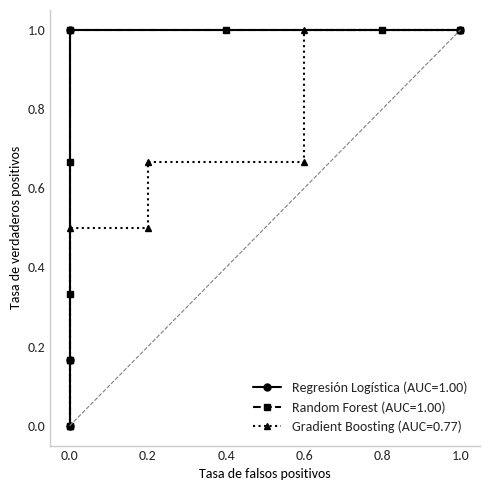

In [ ]:
# Curvas ROC comparativas de los 3 modelos
fig, ax = plt.subplots(figsize=(5,5))

estilos_roc = [
    (modelo_lr_final, "Regresión Logística", "-", "o"),
    (modelo_rf_final, "Random Forest", "--", "s"),
    (modelo_gb_final, "Gradient Boosting", ":", "^")
]

for modelo, nombre, linea, marcador in estilos_roc:
    probas = modelo.predict_proba(X_test_esc)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probas, pos_label="C/S")
    auc_test = roc_auc_score(y_test, probas)
    ax.plot(fpr, tpr, linestyle=linea, marker=marcador, markersize=5,
            color="black", label=f"{nombre} (AUC={auc_test:.2f})")

ax.plot([0,1],[0,1], color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Tasa de falsos positivos", color="black")
ax.set_ylabel("Tasa de verdaderos positivos", color="black")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
ax.grid(False)

plt.tight_layout()
plt.savefig("figura_roc_comparativa.png", dpi=200)
plt.show()

In [ ]:
#  Entrenar el modelo ganador sobre todo el conjunto de entrenamiento
modelo_final = LogisticRegression(penalty="l2", max_iter=1000, random_state=42)
modelo_final.fit(X_train_esc, y_train)

print("Modelo final entrenado ✅")

Modelo final entrenado ✅


In [ ]:
# Evaluar el modelo final sobre el conjunto de validación
predicciones = modelo_final.predict(X_test_esc)
probabilidades = modelo_final.predict_proba(X_test_esc)[:, 1]

auc_final = roc_auc_score(y_test, probabilidades)

print("AUC en el conjunto de validacion:", round(auc_final, 3))
print()
print(classification_report(y_test, predicciones))


AUC en el conjunto de validacion: 1.0

              precision    recall  f1-score   support

         C/A       1.00      0.80      0.89         5
         C/S       0.86      1.00      0.92         6

    accuracy                           0.91        11
   macro avg       0.93      0.90      0.91        11
weighted avg       0.92      0.91      0.91        11



**Figuras del objetivo especifico 2**

In [ ]:
!pip install python-docx -q
from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.6 MB/s eta 0:00:00


In [ ]:
# calibri como fuente para figuras
!apt-get install -y fonts-crosextra-carlito -q
import matplotlib.font_manager as fm
fm.fontManager.addfont("/usr/share/fonts/truetype/crosextra/Carlito-Regular.ttf")
plt.rcParams["font.family"] = "Carlito"
print("Fuente instalada ✅")

Reading package lists...
Building dependency tree...
Reading state information...
Suggested packages:
  fonts-crosextra-caladea
The following NEW packages will be installed:
  fonts-crosextra-carlito
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 743 kB of archives.
After this operation, 2,798 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-crosextra-carlito all 20130920-1.1 [743 kB]
Fetched 743 kB in 1s (1,091 kB/s)
Selecting previously unselected package fonts-crosextra-carlito.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-crosextra-carlito_20130920-1.1_all.deb ...
Unpacking fonts-crosextra-carlito (20130920-1.1) ...
Setting up fonts-crosextra-carlito (20130920-1.1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Fuente instalada ✅


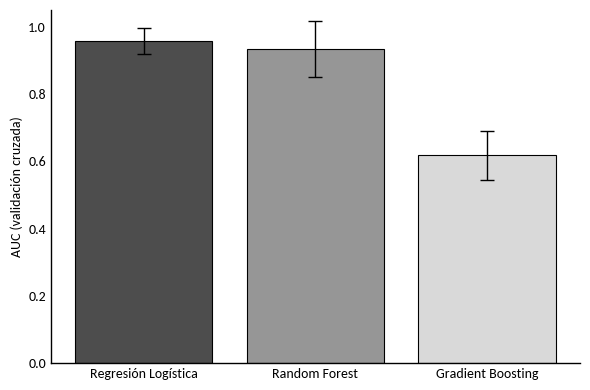

In [ ]:
# Figura comparación de AUC entre los 3 modelos (con barras de error)
import matplotlib.pyplot as plt

modelos_nombres = ["Regresión Logística", "Random Forest", "Gradient Boosting"]
aucs_prom = [resultados_lr.mean(), resultados_rf.mean(), resultados_gb.mean()]
aucs_desvio = [resultados_lr.std(), resultados_rf.std(), resultados_gb.std()]

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(modelos_nombres, aucs_prom,
       yerr=aucs_desvio, capsize=5,
       error_kw=dict(ecolor="black", elinewidth=1),
       color=["#4d4d4d", "#969696", "#d9d9d9"],   # escala de grises
       edgecolor="black", linewidth=0.8)

ax.set_ylabel("AUC (validación cruzada)", color="black")
ax.set_ylim(0,1.05)
ax.grid(False)
ax.tick_params(colors="black")
for etiqueta in ax.get_xticklabels() + ax.get_yticklabels():
    etiqueta.set_color("black")

# Dejar solo los ejes izquierdo e inferior, en negro
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

plt.tight_layout()
plt.savefig("figura2_comparacion_modelos.png", dpi=200)
plt.show()

In [ ]:
# matriz de confusion
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, predicciones, labels=["C/A","C/S"])
print("Matriz de confusión recalculada ✅")
print(matriz)

Matriz de confusión recalculada ✅
[[4 1]
 [0 6]]


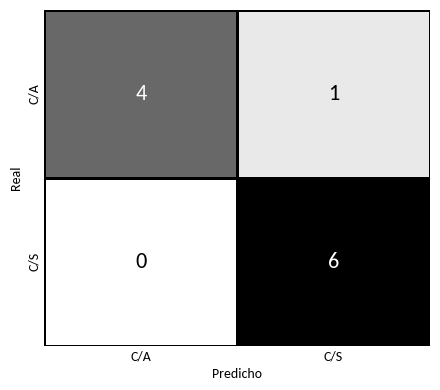

In [ ]:
# figura matriz de confusion
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(4.5,4))

# El color del texto se adapta: blanco sobre fondo oscuro, negro sobre fondo claro
colores_texto = np.where(matriz > matriz.max()/2, "white", "black")

sns.heatmap(matriz, annot=True, fmt="d", cmap="Greys", cbar=False,
            xticklabels=["C/A","C/S"], yticklabels=["C/A","C/S"],
            annot_kws={"size":16, "weight":"bold"},
            linewidths=1, linecolor="black", ax=ax)

# Recorremos cada celda del texto y le asignamos el color correcto
for i, texto in enumerate(ax.texts):
    fila = i // matriz.shape[1]
    columna = i % matriz.shape[1]
    texto.set_color(colores_texto[fila, columna])

ax.set_xlabel("Predicho", color="black")
ax.set_ylabel("Real", color="black")
ax.tick_params(colors="black")
for etiqueta in ax.get_xticklabels() + ax.get_yticklabels():
    etiqueta.set_color("black")

plt.tight_layout()
plt.savefig("figura3_matriz_confusion.png", dpi=200)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

reporte_dict = classification_report(y_test, predicciones, output_dict=True)
tabla_reporte = pd.DataFrame(reporte_dict).transpose().round(2)
tabla_reporte = tabla_reporte.loc[["C/A","C/S"], ["precision","recall","f1-score","support"]]

print("Tabla de reporte recalculada ✅")
tabla_reporte

Tabla de reporte recalculada ✅


,precision,recall,f1-score,support
C/A,1.00,0.8,0.89,5.0
C/S,0.86,1.0,0.92,6.0


In [ ]:
# Word solo con lo del Objetivo 2 (Tabla 3, Figura 2, Tabla 4, Figura 3)
documento = Document()

def agregar_titulo_apa(doc, numero, titulo_texto, tipo="Tabla"):
    p1 = doc.add_paragraph(); r1 = p1.add_run(f"{tipo} {numero}")
    r1.bold = True; r1.font.name="Times New Roman"; r1.font.size=Pt(12)
    p2 = doc.add_paragraph(); r2 = p2.add_run(titulo_texto)
    r2.italic = True; r2.font.name="Times New Roman"; r2.font.size=Pt(12)

def agregar_nota_apa(doc, texto_nota):
    p = doc.add_paragraph(); r = p.add_run("Nota. " + texto_nota)
    r.italic = True; r.font.name="Times New Roman"; r.font.size=Pt(10)

def bordes_horizontales(fila_celdas, arriba=False, abajo=False):
    for celda in fila_celdas:
        tc_pr = celda._tc.get_or_add_tcPr()
        bordes = OxmlElement("w:tcBorders")
        for lado, activo in [("top", arriba), ("bottom", abajo)]:
            if activo:
                b = OxmlElement(f"w:{lado}")
                b.set(qn("w:val"), "single"); b.set(qn("w:sz"), "8"); b.set(qn("w:color"), "000000")
                bordes.append(b)
        tc_pr.append(bordes)

def tabla_word_desde_df(doc, df, incluir_indice=False):
    columnas = (["(clase)"] if incluir_indice else []) + list(df.columns)
    t = doc.add_table(rows=1, cols=len(columnas))
    for i, col in enumerate(columnas):
        t.rows[0].cells[i].text = str(col)
        for p in t.rows[0].cells[i].paragraphs:
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            for r in p.runs: r.font.name="Times New Roman"; r.font.size=Pt(10); r.bold=True
    for idx, fila in df.iterrows():
        celdas = t.add_row().cells
        offset = 0
        if incluir_indice:
            celdas[0].text = str(idx); offset = 1
        for i, col in enumerate(df.columns):
            celdas[i+offset].text = str(fila[col])
        for c in celdas:
            for p in c.paragraphs:
                p.alignment = WD_ALIGN_PARAGRAPH.CENTER
                for r in p.runs: r.font.name="Times New Roman"; r.font.size=Pt(9)
    bordes_horizontales(t.rows[0].cells, arriba=True)
    bordes_horizontales(t.rows[0].cells, abajo=True)
    bordes_horizontales(t.rows[-1].cells, abajo=True)
    return t

# --- Tabla 3: comparacion de modelos ---
agregar_titulo_apa(documento, 3, "Comparación del desempeño (AUC) de los modelos evaluados mediante validación cruzada")
tabla_word_desde_df(documento, comparacion.round(3))
agregar_nota_apa(documento, "AUC = área bajo la curva ROC, obtenida mediante validación cruzada estratificada de 5 particiones. Elaboración propia.")
documento.add_paragraph()

# --- Figura 2 ---
agregar_titulo_apa(documento, 2, "Comparación del AUC promedio entre los modelos evaluados", tipo="Figura")
documento.add_picture("figura2_comparacion_modelos.png", width=Pt(320))
agregar_nota_apa(documento, "Las barras de error representan el desvío estándar del AUC entre las 5 particiones de validación cruzada. Elaboración propia.")
documento.add_paragraph()

# --- Tabla 4: reporte de clasificacion final ---
agregar_titulo_apa(documento, 4, "Métricas de clasificación del modelo final (regresión logística) en el conjunto de validación")
tabla_word_desde_df(documento, tabla_reporte, incluir_indice=True)
agregar_nota_apa(documento, "Modelo evaluado sobre el conjunto de validación independiente (n=11), no utilizado durante el entrenamiento ni la selección del modelo.")
documento.add_paragraph()

# --- Figura 3 ---
agregar_titulo_apa(documento, 3, "Matriz de confusión del modelo final en el conjunto de validación", tipo="Figura")
documento.add_picture("figura3_matriz_confusion.png", width=Pt(260))
agregar_nota_apa(documento, "Filas = clase real; columnas = clase predicha. C/A = Chagas asintomático; C/S = Chagas sintomático.")

documento.save("resultados_objetivo2.docx")
files.download("resultados_objetivo2.docx")
print("Documento del Objetivo 2 generado y descargado ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Documento del Objetivo 2 generado y descargado ✅
